# prep

In [ ]:
account_path = '/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/'

In [ ]:
# mount the drive
from google.colab import drive
drive.mount('/content/drive/')
from google.colab import auth
auth.authenticate_user()

# load packages - basics
!pip install pynrrd
import os
import csv
import numpy as np
import pandas as pd
import math
import time
import json
import nrrd

In [ ]:
# load packages - stats
!pip install scikit-posthocs
import scipy
from scipy import io
from scipy.fftpack import rfft, irfft, fftfreq
import scipy.stats as stats
from scipy.stats import zscore

import statsmodels.api as sm
import statsmodels.formula.api as smf
import scikit_posthocs as scikit
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels

import random
from random import randrange, shuffle
import itertools
from itertools import combinations
import sklearn
from sklearn.decomposition import PCA, FastICA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score

In [ ]:
# load packages - plotting and template settings
import matplotlib as mpl
from matplotlib import pyplot as plt
%matplotlib inline

from matplotlib.patches import Rectangle
import matplotlib.patches as patches
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib import animation
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
import pickle

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## fcn.

In [ ]:
import gspread
from google.auth import default

def read_metadata(gsheet_url,tab_name):
  """This script reads information in a tab in the Google sheet, where metadata for each experiment is stored.
  """
  # import gspread
  # from google.auth import default

  # reading in google sheet with experimental details
  creds, _ = default()
  gc = gspread.authorize(creds)

  # insert URl of gsheet, specify worksheets as different variables
  wb = gc.open_by_url(gsheet_url)
  exps = wb.worksheet(tab_name)

  #
  all_data = pd.DataFrame(exps.get_all_records())
  metadata = all_data.set_index('experiment')
  display(all_data)

  return metadata

In [ ]:
from scipy.interpolate import interp1d
def resample_to_max_length(list_of_arrays):
    max_len = max(len(arr) for arr in list_of_arrays)
    resampled = []
    for arr in list_of_arrays:
        x_old = np.linspace(0, 1, len(arr))
        x_new = np.linspace(0, 1, max_len)
        f = interp1d(x_old, arr, kind='linear', fill_value='extrapolate')
        resampled.append(f(x_new))
    return np.array(resampled), max_len

## config

In [ ]:
# figures output parameters
mpl.rcParams['lines.linewidth'] = 1        # default line width
mpl.rcParams['patch.linewidth'] = 0
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False

# Set global Matplotlib parameters for PDF output
mpl.rcParams['pdf.fonttype'] = 42          # Use TrueType fonts (editable text)

mpl.rcParams['figure.figsize'] = (4,3)     # Default figure size in inches
mpl.rcParams['axes.titlesize'] = 16        # Title font size
mpl.rcParams['axes.labelsize'] = 14        # Axis label font size
mpl.rcParams['xtick.labelsize'] = 10       # X-axis tick label size
mpl.rcParams['ytick.labelsize'] = 10       # Y-axis tick label size
mpl.rcParams['legend.fontsize'] = 8        # Legend font size
mpl.rcParams['savefig.dpi'] = 300          # DPI for high-quality export (relevant for raster elements)
mpl.rcParams['savefig.transparent'] = True # Ensures background is transparent
sns.set(style="white",font_scale=1)     # global scaling of all texts
mpl.rcParams['xtick.bottom'] = True        # make sure ticks visible
mpl.rcParams['ytick.left'] = True

mpl.rcParams['xtick.major.width'] = 0.5    # X-axis major tick width
mpl.rcParams['ytick.major.width'] = 0.5    # Y-axis major tick width
mpl.rcParams['axes.linewidth'] = 0.5       # Axis line width

from cycler import cycler
# remove red from the default colors
mpl.rcParams['axes.prop_cycle'] = cycler('color', ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])

In [ ]:
figure_path = account_path + 'Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/'
csv_path = account_path + 'Yu_escape_paper/Manuscript/Figures/figures_v7/csvs/'

# Data: engagement with virtual fish

In [ ]:
gsheet = 'https://docs.google.com/spreadsheets/d/1bSfcczIO4V62vPDB93Xjm2VDwlayalswnmi6PDiiLps/edit?gid=0#gid=0'
tab_name = 'SE'

experiment_class = f'Social escape - {tab_name}'
path = account_path + 'Yu_escape_paper/Behavior/' + experiment_class

data_path = path + '/Data/'
save_path = path + '/Analysis/'

metadata = read_metadata(gsheet,tab_name)
experiments = metadata.index

,experiment,time_stamps,fish_num,sex,exp_type,fps_Hz,rig_mm,vid_px,body_length,experiment_date,condition
0,vid_1.mp4.000_vid_1.analysis.h5,vid_1.csv,1,M,Panda3D_DC_SE,40,265,800,12,22025,3_trials
1,vid_2.mp4.000_vid_2.analysis.h5,vid_2.csv,1,M,Panda3D_DC_SE,40,265,800,12,22025,3_trials
2,vid_3.mp4.000_vid_3.analysis.h5,vid_3.csv,1,M,Panda3D_DC_SE,40,265,800,12,22025,3_trials
3,vid_4.mp4.000_vid_4.analysis.h5,vid_4.csv,1,M,Panda3D_DC_SE,40,265,800,12,22025,3_trials
4,vid_5.mp4.000_vid_5.analysis.h5,vid_5.csv,1,M,Panda3D_DC_SE,40,265,800,12,22025,3_trials
5,vid_6.mp4.000_vid_6.analysis.h5,vid_6.csv,1,M,Panda3D_DC_SE,40,265,800,12,22025,3_trials
6,vid_8.mp4.000_vid_8.analysis.h5,vid_8.csv,1,F,Panda3D_DC_SE,40,265,800,12,81125,3_trials
7,vid_7.mp4.000_vid_7.analysis.h5,vid_7.csv,1,F,Panda3D_DC_SE,40,265,800,12,81125,3_trials
8,vid_6.mp4.000_vid_6.analysis.h5,vid_6.csv,1,M,Panda3D_DC_SE,40,265,800,12,81125,3_trials
9,vid_5.mp4.000_vid_5.analysis.h5,vid_5.csv,1,M,Panda3D_DC_SE,40,265,800,12,81125,3_trials


In [ ]:
def get_arena_dims(data):
  ArenaDims=pd.DataFrame(data['ArenaDims'].item())
  ArenaDims['Points'] = ArenaDims['Points'].apply(ast.literal_eval)

  #Calculate width based on selected points
  TopXY_L=np.array([ArenaDims['Points'].iloc[0][0][0],ArenaDims['Points'].iloc[0][0][1]])
  TopXY_R=np.array([ArenaDims['Points'].iloc[0][1][0],ArenaDims['Points'].iloc[0][1][1]])
  ArenaWidth=np.sqrt(np.sum(((TopXY_L-TopXY_R)**2))).astype(int)

  #Calculate height based on selected points
  TopXY_R=np.array([ArenaDims['Points'].iloc[0][1][0],ArenaDims['Points'].iloc[0][1][1]])
  BottomXY_R=np.array([ArenaDims['Points'].iloc[0][2][0],ArenaDims['Points'].iloc[0][2][1]])
  ArenaHeight=np.sqrt(np.sum(((TopXY_R-BottomXY_R)**2))).astype(int)


  #Store values in array
  ArenaDims['BBW']=ArenaWidth
  ArenaDims['BBH']=ArenaHeight
  return ArenaDims

# 3a - VR behavior setup

# 3b - distance to VR fish ON vs OFF time series

In [ ]:
def get_escape_data(EllapsedTime,fish_showing,fish_escaping):
    #Pad fish_showing
    fish_showing = np.pad(fish_showing,pad_width=1, mode='constant',constant_values=0)
    fish_escaping = np.pad(fish_escaping,pad_width=1, mode='constant',constant_values=0)


    #normalize to dt
    meanFPS=(len(EllapsedTime)/EllapsedTime[-1]).astype(int)
    #Find transitions in showing/escaping (i.e. start and stop indexes)
    fs_idx=np.where(np.diff(fish_showing.astype(int))==1)[0]
    fse_idx=np.where(np.diff(fish_showing.astype(int))==-1)[0]
    fe_idx=np.where(np.diff(fish_escaping.astype(int))==1)[0]

    ##Fish show output
    start_fs=[]
    end_fs=[]
    for x in range(0,len(fs_idx)):
      start_fs.append(EllapsedTime[fs_idx[x]-1])
    for x in range(0,len(fse_idx)):
      end_fs.append(EllapsedTime[fse_idx[x]-1])

    fs_results=[]
    for start,stop in zip(start_fs,end_fs):
      fs_results.append({"StartFishShowing":start,"EndFishShowing":stop})
    fs_df=pd.DataFrame(fs_results)

    ###Fish escape output
    start_fe=[]
    end_fe=[]
    for x in range(0,len(fe_idx)):
      start_fe.append(EllapsedTime[fe_idx[x]-1])
    for x in range(0,len(fse_idx)):
      end_fe.append(EllapsedTime[fse_idx[x]-1])

    fe_results=[]
    for start,stop in zip(start_fe,end_fe):
      fe_results.append({"StartFishEscaping":start,"EndFishShowing":stop})
    fe_df=pd.DataFrame(fe_results)


    return fs_df,fe_df

In [ ]:
import ast # Import the ast module
ArenaSize_mm = 280 #Arena size in mm
bin_length = 5 #Time bin length in seconds
TimeBeforeStim = 300; TimeAfterStim = 300 # sec

conditions = metadata['condition'].unique(); colors = ['#8B5FBF','#CC5500','red']

for c,con in enumerate(conditions):
  metadata_subset = metadata[metadata['condition']==con]
  results = []

  experiments = metadata_subset.index
  for exp_index,exp in enumerate(experiments):
    # load_path = save_path + f'{metadata_subset.experiment_date[exp]}/' + exp + '/'
    # output_path = save_path + f'{metadata_subset.experiment_date[exp]}/' + exp + '/'

    load_path = os.path.join(save_path,str(metadata_subset['experiment_date'].iloc[exp_index]),metadata_subset.index[exp_index])

    #find all .npz files in load path
    npz_files = []
    for file in os.listdir(load_path):
      if file.endswith('.npz'):
        npz_files.append(file)
    if len(npz_files) == 0 or len(npz_files)>1:
      print(f"Warning in {load_path}...double check .npz file")

    # load data
    data = np.load(load_path+'/'+npz_files[0],allow_pickle=True)
    fish_num, bodylength = data['fish_num'], data['f_bodylength_mm']
    exp_type, f_x, f_y = data['exp_type'], data['f_x'], data['f_y']
    EllapsedTime = data['time_stamps']
    condition = data['condition']
    ArenaDims = get_arena_dims(data)
    ArenaSize = ArenaSize_mm
    scale = ArenaSize/np.array(ArenaDims['BBW'])[0]

    # get distnace to left wall
    TopLeftX = ArenaDims['Points'].values[0][0][0]
    TopLeftY = ArenaDims['Points'].values[0][0][1]
    BottomLeftX = ArenaDims['Points'].values[0][3][0]
    BottomLeftY = ArenaDims['Points'].values[0][3][1]
    m = (TopLeftY-BottomLeftY)/(TopLeftX-BottomLeftX); b = TopLeftY-m*TopLeftX
    dist2line = np.abs(m*f_x-f_y+b)/np.sqrt(m**2+1)

    # get stim status and escape time stamps
    fish_escaping = data['fish_escaping']
    fish_showing = data['fish_showing']
    fs, fe = get_escape_data(EllapsedTime, fish_showing, fish_escaping)

    # get true start time and end time
    start_time = fs['StartFishShowing'].values[0] - TimeBeforeStim
    start_idx = np.nanargmin(np.abs(EllapsedTime - start_time))

    end_time = fs['StartFishShowing'].values[0] - TimeBeforeStim + (TimeBeforeStim*2*4)
    end_idx = np.nanargmin(np.abs(EllapsedTime - end_time))

    # subset data for true start
    EllapsedTime = EllapsedTime[start_idx:end_idx] - EllapsedTime[start_idx]
    dist2line = dist2line[0][start_idx:end_idx]

    TotalTime = np.round(EllapsedTime[-1])

    # bin data
    TimeBins = np.arange(0, TotalTime, bin_length)

    # get time bin indices
    bin_indices = np.clip(np.digitize(EllapsedTime, TimeBins) - 1, 0, len(TimeBins) - 1)

    # create distance array
    DistanceArray = np.full((len(TimeBins) - 1, 1), np.nan)

    for ii in range(len(TimeBins)-1):
      bin_mask = bin_indices == ii
      doi = dist2line[bin_mask]
      DistanceArray[ii, 0] = np.mean(doi)*scale

    results.append(DistanceArray.flatten())

In [ ]:
subpanel = '3b'
# visualize
ConditionArray=np.array(results)

plt.figure(figsize=(4,3))
plt.plot(TimeBins[0:-1]/60,np.nanmean(ConditionArray,axis=0),color='k',lw=0.5)
plt.fill_between(TimeBins[0:-1]/60,np.nanmean(ConditionArray,axis=0)-stats.sem(ConditionArray,axis=0),\
                 np.nanmean(ConditionArray,axis=0)+stats.sem(ConditionArray,axis=0),color='grey',alpha=0.6,lw=0)
for jj in range(len(fe)):
  plt.axvspan(fs['StartFishShowing'].iloc[jj]/60, fs['EndFishShowing'].iloc[jj]/60, color='gray',alpha=0.3)
plt.xlabel('Time (min)'); plt.ylabel('Distance to monitor (mm)')
sns.despine(); plt.xlim(0,40)
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {}
for i, sample in enumerate(ConditionArray):
  col_name = f"group_{i+1}"
  series_dict[col_name] = pd.Series(sample)
df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+".csv",index=False)

# 3c - distance to ON vs OFF stats

,fish_id,average_on,average_off
0,0,90.705125,133.506832
1,1,6.549389,132.824989
2,2,13.178177,84.304663
3,3,115.033998,136.820173
4,4,270.840276,266.731912
5,5,87.987061,112.878517
6,6,12.820593,64.986068
7,7,51.033197,159.609887
8,8,79.155026,143.584133
9,9,85.002400,197.923176


/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/3c


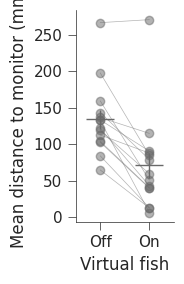

Wilcoxon signed-rank test statistic: 1.0
p-value: 0.000244140625
average_off = 134.38 ± 17.679331152506876
average_on = 71.12 ± 13.333663359010853
delta_mean = -63.26 ± 9.334565826999645


In [ ]:
subpanel = '3c'

OffTime = 300 #seconds
OnTime = 300 #seconds
on_vs_off =TimeBins[0:-1] % (OnTime+OffTime)

on_indices = np.where(on_vs_off > OnTime)[0]
off_indices = np.where(on_vs_off <= OnTime)[0]

summary_list = []
for i in range(ConditionArray.shape[0]):

  fish_data ={'fish_id':i,
              'average_on':np.nanmean(ConditionArray[i,on_indices]),
              'average_off':np.nanmean(ConditionArray[i,off_indices])}
  summary_list.append(fish_data)

fish_df = pd.DataFrame(summary_list)
display(fish_df)
fish_df.to_csv(csv_path+subpanel+".csv",index=False)

# Means for bars
means = [fish_df['average_off'].mean(), fish_df['average_on'].mean()]
sems = [fish_df['average_off'].sem(), fish_df['average_on'].sem()]

fig, ax = plt.subplots(figsize=(2,3))

# Plot mean + sem lines
bar_positions = [0, 1]
# ax.errorbar(bar_positions, means, yerr=sems, fmt="o-", capsize=5, color="dimgrey")
ax.errorbar(bar_positions, means, yerr=sems, fmt="_", markersize=20, markeredgewidth=1,\
        color='dimgrey', capsize=0, elinewidth=1)

# Plot each fish's dots + connecting lines
for _, row in fish_df.iterrows():
    ax.plot(
        bar_positions,
        [row['average_off'], row['average_on']],
        marker='o', color='dimgrey', alpha=0.5, lw=0.5
    )

# Labels
ax.set_xticks(bar_positions)
ax.set_xticklabels(['Off', 'On'])
ax.set_xlabel('Virtual fish')
ax.set_ylabel('Mean distance to monitor (mm)')
plt.xlim(-0.5,1.5)
plt.tight_layout(); sns.despine()
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
plt.show()

#Calulate p value using wilcoxon signed rank test (non-parametric paired test)
from scipy.stats import wilcoxon

# Perform the Wilcoxon signed-rank test
statistic, p_value = wilcoxon(fish_df['average_off'], fish_df['average_on'])
print(f"Wilcoxon signed-rank test statistic: {statistic}")
print(f"p-value: {p_value}")

average_on = np.round(fish_df['average_on'].mean(),2)
average_off = np.round(fish_df['average_off'].mean(),2)
sem_on = np.round(fish_df['average_on'].std(),2)/np.sqrt(fish_df.shape[0])
sem_off = np.round(fish_df['average_off'].std(),2)/np.sqrt(fish_df.shape[0])
delta_mean = np.round(average_on-average_off,2)
sem_std = np.std(fish_df['average_on']-fish_df['average_off'])/np.sqrt(fish_df.shape[0])
print(f"average_off = {average_off} ± {sem_on}")
print(f"average_on = {average_on} ± {sem_off}")
print(f"delta_mean = {delta_mean} ± {sem_std}")

# 3d - Screenshots of triggered escape

# Data: virtual escape (alter num)

In [ ]:
gsheet = 'https://docs.google.com/spreadsheets/d/1bSfcczIO4V62vPDB93Xjm2VDwlayalswnmi6PDiiLps/edit?gid=0#gid=0'
tab_name = 'CL_num'

experiment_class = f'Social escape - {tab_name}'
path = account_path + 'Yu_escape_paper/Behavior/' + experiment_class

data_path = path + '/Data/'
save_path = path + '/Analysis/'

metadata = read_metadata(gsheet,tab_name)
experiments = metadata.index

,experiment,time_stamps,tank,metadata,fish_num,sex,exp_type,fps_Hz,rig_mm,vid_px,body_length,experiment_date,condition
0,vid_1.mp4.000_vid_1.analysis.h5,vid_1.csv,T39,vid_1_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5
1,vid_9.mp4.000_vid_9.analysis.h5,vid_9.csv,T39,vid_9_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5
2,vid_8.mp4.000_vid_8.analysis.h5,vid_8.csv,T39,vid_8_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5
3,vid_7.mp4.000_vid_7.analysis.h5,vid_7.csv,T39,vid_7_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5
4,vid_6.mp4.000_vid_6.analysis.h5,vid_6.csv,T39,vid_6_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5
5,vid_5.mp4.000_vid_5.analysis.h5,vid_5.csv,T39,vid_5_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5
6,vid_4.mp4.000_vid_4.analysis.h5,vid_4.csv,T39,vid_4_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5
7,vid_3.mp4.000_vid_3.analysis.h5,vid_3.csv,T39,vid_3_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5
8,vid_2.mp4.000_vid_2.analysis.h5,vid_2.csv,T39,vid_2_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5
9,vid_11.mp4.000_vid_11.analysis.h5,vid_11.csv,T39,vid_11_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5


In [ ]:
analysis_path = save_path
#Create save directory for analysis
exp_dates = metadata['experiment_date'].tolist()
save_paths = [analysis_path + str(exp_date) for exp_date in exp_dates]
metadata['save_path'] = save_paths
exps=metadata.index
#Add raw data path
data_paths = [data_path + str(exp_date)+'/'+str(exp) for exp_date,exp in zip(exp_dates,exps)]
metadata['raw_data_path'] = data_paths
#Add timestamp path
TimeStamps=metadata['time_stamps'].tolist()
time_stamp_paths = [data_path + str(exp_date)+'/'+str(time) for exp_date,time in zip(exp_dates,TimeStamps)]
metadata['time_stamp_path'] = time_stamp_paths

#Add bounding box path
boxes = [item for item in ['bounding_box_four_corners.csv'] for _ in range(len(metadata))]
box_dim_path=[data_path + str(exp_date)+'/'+str(bbox) for exp_date,bbox in zip(exp_dates,boxes)]
metadata['box_dim_path'] = box_dim_path

#Add metadata path for each video
metadatas = metadata['metadata'].tolist()
metadata_paths = [data_path + str(exp_date)+'/'+str(meta) for exp_date,meta in zip(exp_dates,metadatas)]
metadata['metadata_path'] = metadata_paths

#Get the processed data path for each video
display(metadata)
for exp_date in np.unique(metadata['save_path']):
  os.makedirs(exp_date, exist_ok=True)

processed_data_paths =[]
for i in range(0,len(metadata)):
  exp=metadata.index[i]
  data_path=metadata['raw_data_path'].iloc[i]
  time_stamp_path=metadata['time_stamp_path'].iloc[i]
  save_path_tmp=metadata['save_path'].iloc[i]
  box_dim_path=metadata['box_dim_path'].iloc[i]
  metadata_path=metadata['metadata_path'].iloc[i]
  # processed_data_path=save_npz_geoff(save_path_tmp,exp,'lev0_basics',[],save=False)
  processed_data_path=f'{save_path_tmp}/{exp}/lev0_basics.npz'
  processed_data_paths.append(processed_data_path)
metadata['processed_data_path_basic'] = processed_data_paths

data_path = path + '/Data/'
save_path = path + '/Analysis/'

,time_stamps,tank,metadata,fish_num,sex,exp_type,fps_Hz,rig_mm,vid_px,body_length,experiment_date,condition,save_path,raw_data_path,time_stamp_path,box_dim_path,metadata_path
experiment,,,,,,,,,,,,,,,,,
vid_1.mp4.000_vid_1.analysis.h5,vid_1.csv,T39,vid_1_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_9.mp4.000_vid_9.analysis.h5,vid_9.csv,T39,vid_9_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_8.mp4.000_vid_8.analysis.h5,vid_8.csv,T39,vid_8_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_7.mp4.000_vid_7.analysis.h5,vid_7.csv,T39,vid_7_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_6.mp4.000_vid_6.analysis.h5,vid_6.csv,T39,vid_6_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_5.mp4.000_vid_5.analysis.h5,vid_5.csv,T39,vid_5_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_4.mp4.000_vid_4.analysis.h5,vid_4.csv,T39,vid_4_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_3.mp4.000_vid_3.analysis.h5,vid_3.csv,T39,vid_3_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_2.mp4.000_vid_2.analysis.h5,vid_2.csv,T39,vid_2_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...


In [ ]:
def get_escape_data_alternating(EllapsedTime,fish_showing,fish_escaping,trial_order):
      #Pad fish_showing
    fish_showing = np.pad(fish_showing,pad_width=1, mode='constant',constant_values=0)
    fish_escaping = np.pad(fish_escaping,pad_width=1, mode='constant',constant_values=0)

    #Find transitions in showing fish (i.e. start and stop indexes)
    fs_idx=np.clip(np.where(np.diff(fish_showing.astype(int))==1)[0],0,len(EllapsedTime)-1)
    fse_idx=np.clip(np.where(np.diff(fish_showing.astype(int))==-1)[0],0,len(EllapsedTime)-1)

    ##Fish show output
    start_fs=[]
    end_fs=[]
    for x in range(0,len(fs_idx)):
      start_fs.append(EllapsedTime[fs_idx[x]])
    for x in range(0,len(fse_idx)):
      end_fs.append(EllapsedTime[fse_idx[x]])

    fs_results=[]
    for start,stop in zip(start_fs,end_fs):
      fs_results.append({"StartFishShowing":start,"EndFishShowing":stop})
    fs_df=pd.DataFrame(fs_results)


    #Find transitions in fish escaping
    fe_idx=np.clip(np.where(np.diff(fish_escaping.astype(int))==1)[0],0,len(EllapsedTime)-1)
    fse_idx=np.clip(np.where(np.diff(fish_escaping.astype(int))==-1)[0],0,len(EllapsedTime)-1)

    ###Fish escape output
    start_fe=[]
    end_fe=[]
    for x in range(0,len(fe_idx)):
      start_fe.append(EllapsedTime[fe_idx[x]-1])
    for x in range(0,len(fse_idx)):
      end_fe.append(EllapsedTime[fse_idx[x]-1])

    fe_results=[]
    for start,stop,trial in zip(start_fe,end_fe,trial_order):
      fe_results.append({"StartFishEscaping":start,"EndFishShowing":stop,"NumFishEscape":trial})
    fe_df=pd.DataFrame(fe_results)

    return fs_df,fe_df

## color scheme

['#b7b7b7', '#fc8c3b', '#e95d0d']


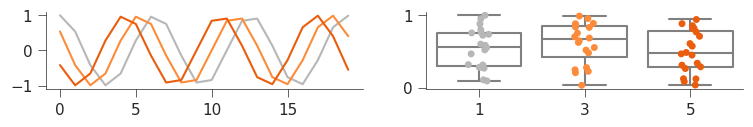

In [ ]:
# RGB hex values theme - for summary stats plots
escp_num = [1,3,5]; group_num = len(escp_num)-1

# get the RGBA from normalized colormap axis
viridis_colors = [cm.Oranges(i/(group_num+4)) for i in range(3,group_num+3)]

viridis_colors = [cm.Grays(100)] + viridis_colors

hex_colors = [f'#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}' for r, g, b, _ in viridis_colors] # Convert RGBA to HEX
print(hex_colors) # ['#abcfe5', '#6aadd5', '#3787c0', '#0f5ba3', '#08306b']
# validate colors settings work with both major plotting packages
plt.figure(figsize=[9,1]); plt.subplot(121);
for igs, gs in enumerate(escp_num): plt.plot(np.cos(np.arange(igs,igs+20)),c=hex_colors[igs]);
tmp = {n: np.random.random(20) for n in escp_num};
plt.subplot(122); sns.boxplot(data=tmp,fill=False,color='gray'); sns.stripplot(data=tmp,palette=hex_colors); sns.despine();
plt.show()

# 3e - example fish trajectory to virtual fish escape

Plotting example from experiment 40425/vid_1.mp4.000_vid_1.analysis.h5: 1 fish, 5 escapees
Condition: 5
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/3e


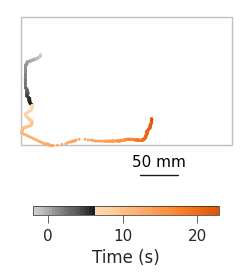

,x,y
0,163.935287,428.644196
1,163.896759,426.074799
2,163.844849,426.109772
3,163.814316,425.911957
4,163.819931,425.808350
...,...,...
628,403.369598,205.179596
629,403.209595,205.352493
630,403.455872,205.617752
631,403.125397,208.111374


In [ ]:
subpanel = '3e'
import ast # Import the ast module
ArenaSize = 280; samples = {}

exp = experiments[0]
load_path = save_path + f'{metadata.experiment_date.iloc[0]}/' + exp + '/'
output_path = save_path + f'{metadata.experiment_date.iloc[0]}/' + exp + '/'

data = np.load(load_path+'lev0_basics.npz', allow_pickle=True)
fish_num, bodylength = data['fish_num'], data['f_bodylength_mm']
exp_type, f_x, f_y = data['exp_type'], data['f_x'], data['f_y']
EllapsedTime = data['time_stamps']
condition = data['condition']
ArenaDims = data['ArenaDims']; ArenaDims = ArenaDims.item()
points = ast.literal_eval(ArenaDims['Points'][0])
ArenaDims = get_arena_dims(data)

trial_order = ast.literal_eval(data['vid_metadata'].item()['trial order']) # Remove this line
con = data['condition']

# Get stim status and escape time stamps
fish_escaping = data['fish_escaping']
fish_showing = data['fish_showing']
fs, fe = get_escape_data_alternating(EllapsedTime, fish_showing, fish_escaping, trial_order)

for escape_event in range(len(fe)):
  # Check if this event has 5 escapees
  if fe["NumFishEscape"].iloc[escape_event] == 5:

    # Get escape time for reference
    escape_time = fe['StartFishEscaping'].iloc[escape_event]

    # Set time window: 5s before and 20s after escape
    start_time = escape_time - 5  # 5 seconds before escape
    end_time = escape_time + 20   # 20 seconds after escape
    start_idx = np.abs(EllapsedTime - start_time).argmin()
    end_idx = np.abs(EllapsedTime - end_time).argmin()

    print(f'Plotting example from experiment {metadata.experiment_date.iloc[0]}/{exp}: {fish_num} fish, 5 escapees')
    print(f'Condition: {condition}')

    # Create the X/Y trajectory plot
    fig, ax = plt.subplots(figsize=[3, 3])

    # Get arena dimensions
    arena_width = ArenaDims['BBW'][0] if 'BBW' in ArenaDims else 1000
    arena_height = ArenaDims['BBH'][0] if 'BBH' in ArenaDims else 1000

    # Add arena boundary
    ax.add_patch(patches.Rectangle(points[0], arena_width, arena_height,
                                  edgecolor=(0, 0, 0, 0.25), facecolor='none', linewidth=1))

    # Define colormap using your original colors
    cmap1 = plt.colormaps['Greys']
    cmap2 = plt.colormaps['Oranges']
    colors = np.vstack((cmap1(np.linspace(0.3, 0.9, 20)),
                        cmap2(np.linspace(0.2, 0.7, 40))))
    combined_cmap = mcolors.ListedColormap(colors)

    # Calculate time relative to escape, but shift so escape is at t=3s
    time_segment = EllapsedTime[start_idx:end_idx]
    # Shift time so that escape_time becomes t=3s
    combined_time = (time_segment - escape_time) + 3

    # Plot X/Y trajectories for each fish
    for fish in range(fish_num):
        x_traj = f_x[fish][start_idx:end_idx]
        y_traj = f_y[fish][start_idx:end_idx]

        # Skip if trajectory is empty
        if len(x_traj) == 0 or len(y_traj) == 0:
            continue

        # Make sure we have matching time data
        min_len = min(len(x_traj), len(y_traj), len(combined_time))
        if min_len > 0:
            # Plot with every 2nd point (like your original ::2)
            plt.scatter(x_traj[:min_len:2], y_traj[:min_len:2],
                        c=combined_time[:min_len:2],
                        cmap=combined_cmap, s=1)
            samples['x'] = x_traj[:min_len:2]
            samples['y'] = y_traj[:min_len:2]

    # Add colorbar below the plot
    cbar = plt.colorbar(label='Time (s)', orientation='horizontal', pad=0.1, shrink=0.8)

    # Formatting
    plt.xticks([])
    plt.yticks([])

    # Add scale bar
    scale = ArenaSize/np.array(ArenaDims['BBW'])[0]
    scale_length_mm = 50
    scale_length_pixels = scale_length_mm / scale
    x_scale = np.arange(arena_width - arena_width/6,
                        arena_width - arena_width/6 + scale_length_pixels)
    y_scale = np.ones(len(x_scale)) * arena_height * 0.08
    plt.plot(x_scale, y_scale-20, c='k', linewidth=1)
    plt.text(np.mean(x_scale), np.mean(y_scale) + arena_height*0.02, '50 mm',
            ha='center', fontsize=11, color='black')

    # Remove spines
    for spine in ax.spines.values():
        spine.set_visible(False)

    print(figure_path+subpanel)
    plt.savefig(figure_path+subpanel+f".pdf", bbox_inches='tight')
    plt.show()

    # save source data into csv
    series_dict = {}
    for key, values in samples.items(): series_dict[key] = pd.Series(values)
    df = pd.DataFrame(series_dict)
    display(df)
    df.to_csv(csv_path+subpanel+f".csv", index=False)

# 3f - distance to VR time series (135)

In [ ]:
# Complile escape data
import ast # Import the ast module

TimeBufferAfter = 12; TimeBufferBefore = 2; FishEscapeTime = 0
distances = []; Times = []; escape_data=[]
ArenaSize=280
conditions = [5,'BG_loom'] # plotting 5 fish escape condition
metadata_subset = metadata
for i in range(len(metadata_subset.index)):

    load_path=metadata_subset['processed_data_path_basic'].iloc[i]
    data = np.load(load_path, allow_pickle=True)
    fish_num, bodylength = data['fish_num'], data['f_bodylength_mm']
    exp_type, f_x, f_y = data['exp_type'], data['f_x'], data['f_y']
    EllapsedTime = data['time_stamps']
    condition = data['condition']
    ArenaDims = get_arena_dims(data)
    trial_order = ast.literal_eval(data['vid_metadata'].item()['trial order'])
    con=data['condition']
    # if con == 'BG_loom':
    #   continue
    fish_id = metadata_subset.index[i] + '_' + str(metadata_subset['experiment_date'].iloc[i])
    # Get distance to left wall
    TopLeftX = ArenaDims['Points'].values[0][0][0]
    TopLeftY = ArenaDims['Points'].values[0][0][1]
    BottomLeftX = ArenaDims['Points'].values[0][3][0]
    BottomLeftY = ArenaDims['Points'].values[0][3][1]
    scale=metadata['rig_mm'].iloc[i]/ArenaDims['BBW'].values

    m = (TopLeftY-BottomLeftY)/(TopLeftX-BottomLeftX); b = TopLeftY-m*TopLeftX
    dist2line = np.abs(m*f_x-f_y+b)/np.sqrt(m**2+1)

    # Get stim status and escape time stamps
    fish_escaping = data['fish_escaping']
    fish_showing = data['fish_showing']
    fs,fe=get_escape_data_alternating(EllapsedTime,fish_showing,fish_escaping,trial_order)

    for escape_event in range(len(fe)):
      start_time = fe['StartFishEscaping'].iloc[escape_event] - TimeBufferBefore
      end_time = fe['StartFishEscaping'].iloc[escape_event] + TimeBufferAfter
      start_idx = np.abs(EllapsedTime - start_time).argmin()
      end_idx = np.abs(EllapsedTime - end_time).argmin()
      trigger_idx = np.abs(EllapsedTime - fe['StartFishEscaping'].iloc[escape_event]).argmin()
      escape_data.append({
          "NumEscapees": fe["NumFishEscape"].iloc[escape_event] if con !='BG_loom' else 'BG_loom',
          "Times": EllapsedTime[start_idx:end_idx] - EllapsedTime[trigger_idx],
          "Distances": dist2line[0][start_idx:end_idx] * scale,
          "Condition":con,
          "FishID":fish_id
      })

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/3f


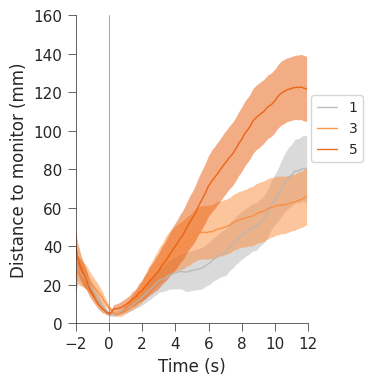

,1_escape_1,1_escape_2,1_escape_3,1_escape_4,1_escape_5,1_escape_6,1_escape_7,1_escape_8,1_escape_9,1_escape_10,...,5_escape_18,5_escape_19,5_escape_20,5_escape_21,5_escape_22,5_escape_23,5_escape_24,5_escape_25,5_escape_26,5_escape_27
0,7.301246,34.124765,27.266968,11.846040,0.606328,13.239087,46.239378,30.790962,62.075063,2.432034,...,12.360944,2.749687,71.126286,NaN,2.241006,3.658040,5.369466,103.552292,2.057110,115.183266
1,8.541334,34.723339,31.461518,10.319608,2.203800,9.458555,38.051808,32.264302,55.291731,2.163249,...,13.413896,3.456776,64.558648,NaN,2.228526,3.720624,4.053100,100.240000,1.745977,107.459955
2,9.490988,34.826253,31.995517,7.556472,2.696992,5.029234,32.716738,32.845565,50.639704,2.471900,...,14.162421,3.610949,59.724407,NaN,1.695890,3.929030,3.780802,94.582774,1.556886,102.367468
3,10.677993,34.935408,32.128852,5.375610,2.433410,4.356469,26.266379,34.302520,45.028809,3.308910,...,14.374095,3.701795,52.901709,NaN,1.639147,3.380597,2.427213,86.254900,1.474200,97.626156
4,11.253336,35.238085,32.188169,1.701963,1.931317,4.737844,17.977044,35.422495,40.171132,3.674409,...,14.998303,3.655248,48.192607,NaN,2.559168,4.011463,0.525210,78.461166,0.743313,90.211568
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,10.497681,0.083634,209.878087,59.968243,128.269541,29.789819,14.139695,2.512868,91.753328,29.720463,...,222.721248,0.237674,106.496814,NaN,237.946406,5.812123,79.297274,259.837813,247.124888,38.655028
135,10.720523,0.243329,212.950571,59.995522,128.831858,27.423619,12.123155,4.498578,94.261789,26.934882,...,220.839584,1.408584,107.775081,NaN,239.118739,5.452049,77.864478,259.901383,256.611414,40.993164
136,11.066351,1.874546,216.364442,59.957542,131.148670,26.387086,10.979338,4.729885,96.155179,22.748198,...,215.887008,2.669476,108.002971,NaN,241.162811,5.091976,77.027999,260.498127,259.205181,42.025454
137,12.224415,2.140975,220.119700,59.865485,133.093450,23.419296,8.466692,5.199458,97.526915,19.264812,...,213.125647,3.804278,109.347504,NaN,242.181507,4.731903,76.060261,259.931450,259.105552,43.936308


In [ ]:
subpanel = '3f'

from scipy.interpolate import interp1d
# Plot average distance to VR screen
tbin = 0.1 # time bin in seconds
TotalTime = TimeBufferAfter + TimeBufferBefore
TimeBins = np.linspace(-TimeBufferBefore, TimeBufferAfter-tbin, int(TotalTime / tbin))
num_escapees = [1,3,5]

plt.figure(figsize=[3,4])
for indx,escapee in enumerate(num_escapees):
  # print(escapee)
  escape_events = [event for event in escape_data if event["NumEscapees"] == escapee]
  Times = [event["Times"] for event in escape_events]
  distances = [event["Distances"] for event in escape_events]
  conditions = [event["Condition"] for event in escape_events]

  # Get time bin indices
  bin_indices = [np.digitize(time_series, TimeBins) - 1 for time_series in Times]

  # Create distance array
  DistanceArray = np.full((len(TimeBins), len(distances)), np.nan)
  for fish_idx in range(len(distances)):
      t = Times[fish_idx]
      d = distances[fish_idx]
      if len(t) > 1:
          # Create an interpolation function for this specific fish
          f = interp1d(t, d, bounds_error=False, fill_value=np.nan)
          DistanceArray[:, fish_idx] = f(TimeBins)

  DistanceMean=np.nanmean(DistanceArray,axis=1)
  DistanceSEM=(np.nanstd(DistanceArray,axis=1)/np.sqrt(DistanceArray.shape[1]))
  plt.plot(TimeBins, DistanceMean, linewidth=1,alpha=0.9,color=hex_colors[indx], label=f'{escapee}')
  plt.fill_between(TimeBins, (DistanceMean- DistanceSEM), (DistanceMean+ DistanceSEM), alpha=0.5,color=hex_colors[indx],lw=0)

plt.ylabel('Distance to monitor (mm)')
plt.xlabel('Time (s)'); plt.xlim(-TimeBufferBefore,TimeBufferAfter); plt.xticks(np.arange(-TimeBufferBefore,TimeBufferAfter+1,2))
plt.ylim(0,160)
plt.axvline(0,c='grey',lw=0.5);
plt.legend(bbox_to_anchor=(1,0.75),handlelength=1.5,markerscale=0.7,borderaxespad=0.2,fontsize=10)
sns.despine()
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
plt.show()

# compile data for csv and for summary
series_dict = {}

for indx,escapee in enumerate(num_escapees):
  escape_events = [event for event in escape_data if event["NumEscapees"] == escapee]
  Times = [event["Times"] for event in escape_events]
  distances = [event["Distances"] for event in escape_events]

  # Get time bin indices
  bin_indices = [np.digitize(time_series, TimeBins) - 1 for time_series in Times]
  DistanceArray = np.full((len(TimeBins) - 1, len(distances)), np.nan)
  for fish in range(len(distances)):
      for i in range(len(TimeBins) - 1):
          bin_mask = bin_indices[fish] == i
          doi = distances[fish][bin_mask]
          if len(doi) > 0:
              DistanceArray[i, fish] = np.nanmean(doi)

  for j in range(DistanceArray.shape[1]):
    col_name = f'{escapee}_escape_{j+1}'
    series_dict[col_name] = pd.Series(DistanceArray[:,j])

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+f".csv", index=False)

# 3g - distance to VR stats (135)

In [ ]:
from scipy.stats import friedmanchisquare
try:
  import scikit_posthocs as sp
except:
  !pip install scikit-posthocs
  import scikit_posthocs as sp
import pandas as pd

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/3g


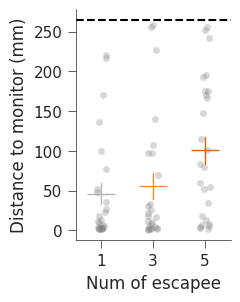

Ns, means, and  sems for data:
1: (N=26) 45.839, 13.181
3: (N=26) 55.672, 15.775
5: (N=26) 100.445, 17.018
--- Omnibus Test Results ---
Friedman chi-squared: 6.2308
p-value: 0.0444

Significant difference found! Running Dunn post-hoc test...

--- Post-Hoc p-values Matrix ---
          Stim_1    Stim_3    Stim_5
Stim_1  1.000000  0.690793  0.028399
Stim_3  0.690793  1.000000  0.056046
Stim_5  0.028399  0.056046  1.000000


,1_escapee,3_escapee,5_escapee
0,22.837396,32.570366,18.038715
1,1.866554,107.055007,34.262393
2,9.036306,257.895673,175.647117
3,48.711471,69.642558,100.816769
4,35.139792,1.112905,242.424777
5,6.258877,30.214597,79.224250
6,217.174114,16.771200,251.988948
7,3.045670,97.673764,54.876158
8,13.473171,139.854749,166.072041
9,3.942818,25.197243,174.937860


In [ ]:
subpanel = '3g' # run 3f block first

escape_df = pd.DataFrame(escape_data)
start_time = 5 # sec
end_time = 12
stim_1_data = []; stim_3_data = []; stim_5_data = []
escape_summary =[]
fish_ids = escape_df['FishID'].unique()
for fish in fish_ids:

  fish_data = escape_df[escape_df['FishID'] == fish]
  num_escapees = fish_data["NumEscapees"]
  times = fish_data["Times"]
  distances = fish_data["Distances"]

  # Check if data is valid (not empty and has sufficient length)
  if len(times) == 0 or len(distances) == 0 or len(times) != len(distances):
      continue

  for time,dist,escapees in zip(times,distances,num_escapees):
    # Find index for 10 seconds after stimulus (t=3s is stimulus onset)
    start_idx = np.searchsorted(time, start_time)
    end_idx   = np.searchsorted(time, end_time)

    if end_idx <= start_idx:
      continue

    # Get distance at that time point
    distance_at_target = np.nanmedian(dist[start_idx:end_idx])
    escape_summary.append({
                      'Fish_ID':fish,
                      'Distance':distance_at_target,
                      'num_escapees':escapees})

    # Store by group for stats
    if escapees == 1:
      stim_1_data.append(distance_at_target)
    elif escapees == 3:
      stim_3_data.append(distance_at_target)
    elif escapees == 5:
      stim_5_data.append(distance_at_target)

# PLOT
paired_df = pd.DataFrame(escape_summary)
paired_df = paired_df[paired_df['num_escapees'].isin([1, 3, 5])].copy()

plt.figure(figsize=[2,3])
plt.axhline(y=265,linestyle='--',color='black')

sns.stripplot(data=paired_df,x='num_escapees',y='Distance',order=[1, 3, 5],\
              color='gray',alpha=0.3,size=5)
sns.pointplot(data=paired_df,x='num_escapees',y='Distance',order=[1, 3, 5],\
              palette=hex_colors,linestyle="none",marker="_",estimator='mean',errorbar='se',markersize=20,markeredgewidth=1,errwidth=1);
plt.xlabel('Num of escapee'); plt.ylabel('Distance to monitor (mm)')
sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
plt.show()

# stats
print("Ns, means, and  sems for data:")
for escapee, data in zip([1,3,5],[stim_1_data,stim_3_data,stim_5_data]):
  print(f'{escapee}: (N={len(data)}) {np.nanmean(data):.3f}, {scipy.stats.sem(data):.3f}')

# Friedman Test
# Replace these with your actual extracted distance/speed data arrays
stat, p_val = friedmanchisquare(stim_1_data, stim_3_data, stim_5_data)

print("--- Omnibus Test Results ---")
print(f"Friedman chi-squared: {stat:.4f}")
print(f"p-value: {p_val:.4f}")

# Post-Hoc Analysis
if p_val < 0.05:
    print("\nSignificant difference found! Running Dunn post-hoc test...")

    # Post-hoc libraries usually prefer long-format DataFrames
    # Let's mock up a long DataFrame from your arrays
    n_fish = len(stim_1_data)
    df = pd.DataFrame({
        'Response': np.concatenate([stim_1_data, stim_3_data, stim_5_data]),
        'Stimulus': ['Stim_1']*n_fish + ['Stim_3']*n_fish + ['Stim_5']*n_fish,
        'Fish_ID': list(range(n_fish)) * 3
    })

    # Run Conover's test with Holm-Bonferroni correction
    posthoc_matrix = sp.posthoc_dunn(
        df,
        val_col='Response',
        group_col='Stimulus',
        p_adjust='holm'
    )

    print("\n--- Post-Hoc p-values Matrix ---")
    print(posthoc_matrix)
else:
    print("\nNo significant differences found between the three stimulus types.")

# save source data into csv
series_dict = {}
for key, values in zip([1,3,5],[stim_1_data,stim_3_data,stim_5_data]):
  series_dict[f'{key}_escapee'] = pd.Series(values)

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+f".csv", index=False)